# 🧭 Tutorial: Importing and Exporting Graphs with Spanner for GNN Development

### What is Spanner Graph?
[Google Cloud Spanner Graph](https://cloud.google.com/spanner/docs/graph/overview) is a graph database interface built on top of the Spanner relational database. It allows you to model your data as a property graph (nodes and edges) over relational tables and query it using GQL (Graph Query Language).

### About this tutorial
This tutorial provides a bridge between **Spanner Graph** and **Graph Flow (DGF)**. It guides you through the process of migrating the OGB Arxiv dataset (a massive citation network of CS papers) into Google Cloud Spanner and then retrieving it for analysis.

In this notebook, we will cover:
1.  **Dataset Preparation**: We use dgf.io.dataset_loader to load the ogbn-arxiv benchmark into memory.
2.  **Schema Refinement:** We clean and adapt the schema for Spanner (e.g., fixing data types and removing training artifacts).
3.  **High-Scale Ingestion**: We write 169k nodes and 1.1M edges into Spanner Graph using an optimized, batched writer that handles type conversion and transaction limits.
4.  **Distributed Reading**: We read the graph back from Spanner using Apache Beam to handle the scale.
5.  **Sampling & Visualization**: Since the full graph is too large to plot, we use Beam to sample a representative subgraph, load it back into memory, and visualize the citation network topology using `dgf.plot`.

### Prerequisites
To run this tutorial, you need:
* A Google Cloud Project with the Spanner API enabled.
* A Spanner Instance (e.g., my-spanner-instance).
    * Note: This notebook will create the Database and Graph tables inside this instance for you.
* A Cloud Storage Bucket (for staging temporary files).
* Standard permissions to Create Databases, Write Data, and Execute DDL statements in Spanner.

## Installing DGF

Internally, DGF is available as the `//third_party/py/dgf` Blaze rule. To use
DGF, add it to your `colab_binary`.

Alternatively, we pre-configured two `colab_binary`. In a shell, run:

```shell
# Run a colab instance locally
blaze run -c opt //third_party/py/dgf:notebook_cpu

# Run a colab instance locally with GPU support.
blaze run -c opt //third_party/py/dgf:notebook_accelerator

# Run a colab instance on XM on GPU
# Warning: Plotting are computed with GraphViz, which is not (?) available
# with this option.
# TODO(gbm): Allow graph plotting with XM.
alias colab=/google/bin/releases/grp-ix-team/rapid/colab-cli/cli.par
colab launch //third_party/py/dgf:notebook_accelerator.par --xm_resource_pool=cml --xm_resource_alloc=cml/cml-shared-ml-user --accelerator=v100=1 --noxm_monitor_on_launch --label=dgf_gpu_colab
```

Externally, DGF is installed with `pip install dgf -U`.

**Note:** The `dgf` package is not yet published.

Once installed, import DGF as follow:

In [1]:
import dgf
import numpy as np

### 📊 About the OGB Arxiv Data in Spanner

For this tutorial, we are using the **[OGB Arxiv](https://ogb.stanford.edu/docs/nodeprop/#ogbn-arxiv)** citation network. This dataset represents a network of Computer Science arXiv papers, where nodes are papers and edges represent citations.

The data is stored in Spanner using the following **Property Graph Schema**, derived automatically from the dataset loader:

**1. Nodes Table (`nodes`)**
Represents the papers.
* **`id`** (STRING): The unique identifier for the paper.
* **`node_pred_label_0`** (INT64): The subject category of the paper (used as the label for classification tasks).
* **`initial_state`** (ARRAY<FLOAT64>):A 128-dimensional feature vector representing the paper's content (word embeddings of title and abstract).

**2. Edges Table (`edges`)**
Represents the citation links.
* **`source`** (STRING): The ID of the paper citing another paper.
* **`target`** (STRING): The ID of the paper being cited.

**3. Graph Definition (`ogbn_arxiv`)**
The property graph `ogbn_arxiv` maps these tables to graph elements:
* **Node Label:** `nodes`
* **Edge Label:** `edges`  (Directed: source $\to$ target)

In [2]:
# @title Import Libraries
import logging

import apache_beam as beam
from apache_beam.options.pipeline_options import PipelineOptions
from google.api_core import exceptions
from google.cloud import spanner_v1

## Configuration & Schema Visualization

First, let's configure our connection to Spanner.

We are targeting the **OGB Arxiv** dataset. Since Spanner stores arrays as variable-length, we must explicitly tell our loader that the `initial_state` embedding has a fixed size of `(128,)`.

Once configured, we can use `dgf.plot.plot_schema` to visualize exactly what our graph looks like without reading any data yet.

In [3]:
# @title Configuration
# Configure your Google Cloud Project and Spanner details here
PROJECT_ID = "biggraphs-poc"  # @param {type:"string"}
INSTANCE_ID = "spanner-gnn"  # @param {type:"string"}
DATABASE_ID = "ogbn_arxiv"  # @param {type:"string"}
GRAPH_ID = "ogbn_arxiv"  # @param {type:"string"}


# Temporary location for Dataflow/Beam staging
TEMP_LOCATION = f"gs://{PROJECT_ID}-dataflow/temp"

logging.getLogger().setLevel(logging.INFO)
print(f"Configured for Graph: {GRAPH_ID} in Project: {PROJECT_ID}")

Configured for Graph: ogbn_arxiv in Project: biggraphs-poc


## Load and Inspect the Dataset
We begin by loading the ogbn-arxiv dataset into an in-memory graph structure. This dataset is a standard benchmark from the Open Graph Benchmark (OGB) suite.

**Dataset Overview:**

**Domain**: A directed citation network of Computer Science arXiv papers.

**Nodes**: 169,343 papers. Each node has features (128-dimensional word embeddings of the title/abstract) and a label (the subject area of the paper).

**Edges**: 1,166,243 citations. An edge from paper A to paper B means A cites B.


---


**Why print the schema?**
The print statements below allow us to inspect the raw data structure (feature shapes and data types). This inspection is crucial for the next steps, where we will need to clean the schema (e.g., fixing scalar vs. array types) to ensure it is compatible with Spanner.

In [4]:
# @title Loading Graph using Dataset loader and Plot Schema

print('Loading OGB Arxiv dataset... (This may take a minute)')
in_memory_graph, graph_schema = dgf.io.fetch_ogb_graph('ogbn-arxiv')


print('\n--- Graph Summary ---')
print(f'In Memory Graph: %s', in_memory_graph)
print(f'Nodes: {in_memory_graph.node_sets["nodes"].num_nodes}')
print(f'Edges: {in_memory_graph.edge_sets["edges"].adjacency.shape[1]}')

print('\n--- Raw Schema ---')
print(dgf.analyse.print_schema(graph_schema))

Loading OGB Arxiv dataset... (This may take a minute)


Downloaded 0.08 GB: 100%|██████████| 81/81 [00:03<00:00, 21.84it/s]


Extracting /tmp/dataset_ogb/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 14364.05it/s]

Saving...



--- Graph Summary ---
In Memory Graph: %s InMemoryGraph(node_sets={'nodes': InMemoryNodeSet(num_nodes=169343, features={'#split': array([b'train', b'train', b'train', ..., b'test', b'test', b'test'],
      shape=(169343,), dtype='|S5'), 'node_pred_label_0': array([ 4,  5, 28, ..., 10,  4,  1], shape=(169343,)), '#id': array([b'v0', b'v1', b'v2', ..., b'v169340', b'v169341', b'v169342'],
      shape=(169343,), dtype='|S7'), 'initial_state': array([[-0.057943, -0.05253 , -0.072603, ...,  0.173364, -0.172796,
        -0.140059],
       [-0.1245  , -0.070665, -0.325202, ...,  0.068524, -0.372111,
        -0.301036],
       [-0.080242, -0.023328, -0.183787, ...,  0.109919,  0.117589,
        -0.139883],
       ...,
       [-0.22053 , -0.036568, -0.402199, ...,  0.11336 , -0.161393,
        -0.145171],
       [-0.138236,  0.040885, -0.251811, ..., -0.08929 , -0.041253,
        -0.376132],
       [-0.029875,  0.268417, -0.161124, ...,  0.120807,  0.077647,
        -0.091018]], shape=(169343,

**The Schema**:

*   **Graph Name**: `ogbn_arxiv`
*   **Node Table**: `nodes` (All columns become node properties)
*   **Edge Table**: `edges` (All columns become edge
properties), linking Source $\to$  Destination.


--- Visualizing Graph Schema ---


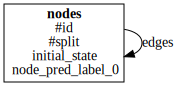

In [5]:
print('\n--- Visualizing Graph Schema ---')
dgf.plot.plot_schema(graph_schema)

## Data Ingestion: Writing the Graph to Spanner

Now that our tables (`nodes` and `edges`) are created with the correct schema, we proceed to define the Property Graph layer and load the actual data. This step involves writing approximately **169,000 nodes** and **1.1 million edges** into Spanner.


**Key Actions Performed:**

* **Lifecycle Management**: Checks if the graph exists and, if `overwrite=True`, automatically drops and recreates the database tables to ensure a clean slate.

* **Schema Customization:**

  * **Filtering**: Excludes training features (e.g., `'#split'`) from the schema, in order to omit the training masks from the database table, keeping the schema focused on core graph properties.

  * **Type Overrides**: Forces IDs to `STRING` (UTF-8) instead of `BYTES` to ensure readability, avoiding Base64 encoding for identifiers like "id":"v0".

* **Graph Definition**: Automatically executes the `CREATE PROPERTY GRAPH` statement. This maps the physical node and edge tables to a logical graph structure, enabling GQL (Graph Query Language) immediately after ingestion.

* **Data Ingestion**:

  * **Scale**: Writes approximately 169,000 nodes and 1.1 million edges to Spanner.

  * **Reliability**: Automatically manages transaction boundaries and dependencies (creating nodes before edges) to prevent foreign key violations and timeout errors.

* **Verification**: Reloads database metadata immediately after creation to guarantee that the physical tables match the logical graph definition.

Note: This process may take a few minutes to complete as it uploads ~1.2 million rows.

In [6]:
dgf.io.write_spanner_graph_from_graph(
    project_id=PROJECT_ID,
    instance_id=INSTANCE_ID,
    database_id=DATABASE_ID,
    graph_id=GRAPH_ID,
    in_memory_graph=in_memory_graph,
    graph_schema=graph_schema,
    exclude_features_from_schema={'nodes': ['#split']},
    node_features_as_strings={'nodes': ['#id']},
    edge_features_as_strings={'edges': ['#id']},
    overwrite=True,
    verbose=True,
)
print('Data written successfully to Spanner Graph.')

print('\n🔍 Verify your data in Spanner Studio:')
console_url = (
    f'https://console.cloud.google.com/spanner/instances/{INSTANCE_ID}/'
    f'databases/{DATABASE_ID}/details/query?project={PROJECT_ID}'
)
print(f'🔗 {console_url}')

'overwrite=True': Dropping existing graph 'ogbn_arxiv'.
Deleting Property Graph 'ogbn_arxiv'.
Note: Graph drop failed or skipped (400 Error parsing Spanner DDL statement: DROP PROPERTY GRAPH ogbn_arxiv IF EXISTS : Syntax error on line 1, column 32: Expecting 'EOF' but found 'IF')
Deleting Physical Tables.
Creating Spanner tables from GraphSchema.
Excluded '#split' from Node Set 'nodes'
Node Set 'nodes': Updated '#id' to UTF-8 STRING
current_ddl_statement for node set nodes: CREATE TABLE nodes (node_pred_label_0 INT64,id STRING(MAX) NOT NULL,initial_state ARRAY<FLOAT32>) PRIMARY KEY (id)
ddl_statements for node set nodes: CREATE TABLE nodes (node_pred_label_0 INT64,id STRING(MAX) NOT NULL,initial_state ARRAY<FLOAT32>) PRIMARY KEY (id)
edge_set_name: edges
edge_set_schema: EdgeSchema(source='nodes', target='nodes', features={})
current_ddl_statement for edge set edges: CREATE TABLE edges (source STRING(MAX) NOT NULL,target STRING(MAX) NOT NULL,) PRIMARY KEY (source, target)
DDL for Prope

Writing nodes: 100%|██████████| 169343/169343 [00:38<00:00, 4348.56nodes/s]



Wrote 169343 nodes to node table nodes
Processing Edge Table: edges


Writing edges: 100%|██████████| 1166243/1166243 [00:59<00:00, 19563.86edges/s]


Wrote 1166243 edges to edge table edges
Write operation complete.
Data written successfully to Spanner Graph.

🔍 Verify your data in Spanner Studio:
🔗 https://console.cloud.google.com/spanner/instances/spanner-gnn/databases/ogbn_arxiv/details/query?project=biggraphs-poc


## Distributed (Beam) Execution - Reading Loaded Spanner Graph Data

Now we will run a **distributed Apache Beam pipeline** to read the actual data from Spanner Graph.

This pipeline will:

*   **Connect**: Use the efficient `ReadFromSpanner` transform
to scan the database.

*   **Sample**: Select a few nodes and edges from the huge dataset.

*   **Verify**: Print the results to confirm that features (like our 128-dim embedding `initial_state`) are loading correctly.

Note: For large graphs, using a distributed pipeline is essential. While this tutorial runs locally (`DirectRunner`), the same code can scale to billions of edges on Dataflow.

### **🔧 Prerequisite: Fixing the Expansion Service**
Since we are using Python to run a Java-based connector (SpannerIO), Beam uses a "Cross-Language Expansion Service."

If you are running this in a development environment (like Colab), Beam might detect a "dev" version of the library and fail to find the corresponding Java JARs. The code below patches this by forcing Beam to download the stable **2.54.0** JARs from Maven, ensuring the connector works seamlessly.

In [7]:
# @title 🔧 Fix: Force Download of Expansion Service JAR
import apache_beam.utils.subprocess_server


def apply_expansion_service_patch():
  """Patches Beam to force downloading stable JARs for Cross-Language transforms.

  Fixes 'RuntimeError' when running in dev environments (e.g., Colab).
  """
  # 1. Target the class responsible for finding/launching the JARs
  ServerClass = apache_beam.utils.subprocess_server.JavaJarServer

  # 2. Safety Check: Only apply the patch if we haven't already
  if not hasattr(ServerClass, "_original_path_to_beam_jar"):
    ServerClass._original_path_to_beam_jar = ServerClass.path_to_beam_jar

    # 3. Define the patched method
    @classmethod
    def patched_path_to_jar(
        cls,
        gradle_target,
        appendix=None,
        version=None,
        artifact_id=None,
        maven_repository_url=None,
    ):
      # Force a specific stable version known to have valid JARs on Maven
      FORCED_VERSION = "2.54.0"

      # Call the original logic with the spoofed version
      return cls._original_path_to_beam_jar(
          gradle_target,
          appendix,
          FORCED_VERSION,
          artifact_id,
          maven_repository_url,
      )

    # 4. Apply the patch to the class
    ServerClass.path_to_beam_jar = patched_path_to_jar
    print(
        "Patch Applied: Beam Expansion Service will now be downloaded"
        " automatically."
    )
  else:
    print("Patch already active.")


# Apply it immediately
apply_expansion_service_patch()

Patch Applied: Beam Expansion Service will now be downloaded automatically.


## Execute the Verification Pipeline
With the environment patched, we can now launch the pipeline.

The code below performs the following steps:

* Connects to the ogbn_arxiv graph in Spanner.

* Reads the nodes and edges PCollections (parallel collections of data).

* Samples 3 random elements from each collection.

* Prints the IDs and feature shapes to the console.

**Success Criteria:**
You should see output logs starting with [NODE] and [EDGE], confirming that the 128-dimensional `initial_state` array was retrieved correctly.

In [8]:
# @title Run Beam Pipeline
print("This might take a while, since the graph is huge.")

# Define Pipeline Options
pipeline_options = PipelineOptions(
    runner="DirectRunner", project=PROJECT_ID, temp_location=TEMP_LOCATION
)

# Define Spanner Graph loaded above
spanner_graph_config = dgf.io.SpannerGraph(
    project_id=PROJECT_ID,
    instance_id=INSTANCE_ID,
    database_id=DATABASE_ID,
    graph_id=GRAPH_ID,
)

print(f"Starting Beam Pipeline to read from: {GRAPH_ID}...")
print(f"- Goal: Compute Feature Statistics")

with beam.Pipeline(options=pipeline_options) as p:
  # Load the graph into a Distributed Graph (dgf) object
  dgf_graph = spanner_graph_config.read_from_spanner_graph(p)

  # Compute & Print Statistics
  # We calculate stats (mean/std/counts) for all features in parallel
  stats = dgf.beam.analyse.feature_statistics(dgf_graph)

  (
      stats
      | "FormatStats" >> beam.Map(lambda s: f"\n📊 FEATURE STATISTICS:\n{s}")
      | "PrintStats" >> beam.Map(print)
  )

print(f"\n✅ Pipeline complete.")

This might take a while, since the graph is huge.
Starting Beam Pipeline to read from: ogbn_arxiv...
- Goal: Compute Feature Statistics



📊 FEATURE STATISTICS:
GraphFeatureStatistics:
  Node Sets (1):
    'nodes':
      'id': count=169343, min=nan, max=nan
      'initial_state': count=169343, min=-1.3889, max=1.6387, quantiles=(100)[-0.7375, -0.4670, -0.4092, ..., 0.6834, 0.8375, 1.1547]
      'node_pred_label_0': count=169343, min=0.0000, max=39.0000, quantiles=(100)[0.0000, 2.0000, 2.0000, ..., 37.0000, 39.0000, 39.0000]


✅ Pipeline complete.


## Verification: Load Spanner Graph into Memory
Now that the data is persisted in Spanner, we can read it back into an in-memory graph object to verify data integrity.

Note: This method loads the entire graph into RAM. This works fine for the OGB Arxiv dataset (~169k nodes), but for massive graphs, you should use the Distributed Beam approach shown previously.

This step confirms that:

* **Connection**: We can successfully connect to the ogbn_arxiv property graph.

* **Schema Inference**: The schema (tables, columns, types) is correctly inferred from the database.

* **Data Integrity**: The node/edge counts and feature shapes match what we originally loaded.

* **Enable Local Analysis:** Once in memory, we can easily run local sampling, plotting, and statistics using standard Python tools.

* **Export**: Save the graph to disk (GCS) in the optimized GraphFlow format for future training.

We use the `read_spanner_graph_to_in_memory_graph` function, which returns the graph data object and its schema.

> **Note:** This method loads the **entire graph** into RAM. This is perfect for the OGB Arxiv dataset (~169k nodes), but for terabyte-scale graphs, you should use the Distributed Beam approach shown earlier.

### Loading Spanner Graph to In-Memory Graph.

In [10]:
print(f"📥 Reading graph '{GRAPH_ID}' into memory... (This may take a minute)")
in_memory_graph_loaded, loaded_schema = dgf.io.read_graph_from_spanner_graph(
    project_id=PROJECT_ID,
    instance_id=INSTANCE_ID,
    database_id=DATABASE_ID,
    graph_id=GRAPH_ID,
    internal_config=spanner_graph_config,
)

print("\n✅ Graph Loaded Successfully!")

# Verify Counts
print("\n--- Verification Stats ---")
print("\nNumber of nodes:", in_memory_graph_loaded.node_sets["nodes"].num_nodes)
print(
    "\nNumber of edges:",
    in_memory_graph_loaded.edge_sets["edges"].adjacency.shape[1],
)

if "nodes" in in_memory_graph_loaded.node_sets:
  count = in_memory_graph_loaded.node_sets["nodes"].num_nodes
  print(f"Nodes Loaded: {count}")
  # Expected: ~169,343

if "edges" in in_memory_graph_loaded.edge_sets:
  # Check edges by looking at the adjacency matrix shape
  edge_count = in_memory_graph_loaded.edge_sets["edges"].adjacency.shape[1]
  print(f"Edges Loaded: {edge_count}")
  # Expected: ~1,166,243

# Verify Features
# Check if 'node_pred_label_0' exists and has the correct shape
if "node_pred_label_0" in in_memory_graph_loaded.node_sets["nodes"].features:
  lbl_shape = (
      in_memory_graph_loaded.node_sets["nodes"]
      .features["node_pred_label_0"]
      .shape
  )
  print(f"Label Feature Shape: {lbl_shape}")

if "initial_state" in in_memory_graph_loaded.node_sets["nodes"].features:
  feat_shape = (
      in_memory_graph_loaded.node_sets["nodes"].features["initial_state"].shape
  )
  print(f"Embedding Feature Shape: {feat_shape}")


# Export to Disk/GCS
# Setup Paths
output_path = f"{TEMP_LOCATION}/exported_graph"
# We write the graph to the efficient GraphFlow binary format
dgf.io.write_graph(in_memory_graph_loaded, loaded_schema, output_path, True)

📥 Reading graph 'ogbn_arxiv' into memory... (This may take a minute)
Connecting to Spanner Graph: Project biggraphs-poc, Instance spanner-gnn, Database ogbn_arxiv
Reading nodes of node set nodes from Spanner Graph
The Node Properties of Node Table nodes: ['id', 'initial_state', 'node_pred_label_0', '#id']
Number of nodes in node table nodes: 169343
Reading edges from Spanner Graph
The Edge Properties of Edge Table edges: ['source', 'target', '#id']
Number of edges in edge table edges: 1166243

✅ Graph Loaded Successfully!

--- Verification Stats ---

Number of nodes: 169343

Number of edges: 1166243
Nodes Loaded: 169343
Edges Loaded: 1166243
Label Feature Shape: (169343,)
Embedding Feature Shape: (169343, 128)
Writing schema to gs://biggraphs-poc-dataflow/temp/exported_graph/schema.json
Writing metadata to gs://biggraphs-poc-dataflow/temp/exported_graph/metadata.json
Writing nodeset nodes to gs://biggraphs-poc-dataflow/temp/exported_graph/nodesets
Writing shard 1/100 to gs://biggraphs-

## Validate the Graph Structure
Before proceeding with any analysis or writing to Spanner, it is crucial to verify that our graph object is valid.

What is a Graph in DGF?
In this library, a Graph is essentially a Python Dataclass backed by NumPy arrays.

* **Features**: Stored as arrays (e.g., node labels, embeddings).

* **Adjacency**: Stored as arrays defining the connections between nodes.

We use `dgf.validate.validate_graph` to ensure that:

1. All feature lengths match the number of nodes.

2. Adjacency indices point to valid node IDs.

3. The structure matches the defined schema.

**Remark**: You might see warnings about missing features or type mismatches. While warnings are acceptable for this tutorial, resolving them is recommended for production pipelines to avoid subtle bugs.

In [11]:
print("Running graph validation...")
dgf.validate.validate_graph(
    in_memory_graph_loaded, loaded_schema, raise_on_warning=False
)

Running graph validation...
[WARNING] The feature 'id' in nodeset 'nodes' has no semantic type defined in the schema. This will make the feature harder to consume by some tools.
[WARNING] The feature 'source' in edgeset 'edges' has no semantic type defined in the schema. This will make the feature harder to consume by some tools.
[WARNING] The feature 'target' in edgeset 'edges' has no semantic type defined in the schema. This will make the feature harder to consume by some tools.


**Note:** Warnings are okay for this toy example, but for real graphs, solving
them might help you avoid bugs.

### Generate GraphFeatureStatistics

Let's show how to run algorithms on the graph. For example, let's compute statistics and dictionaries for the features. This is a critical step for Preprocessing:

* **Numerical Features**: We need Mean and Standard Deviation to normalize inputs (e.g., centering embeddings).

* **Categorical Features**: We need unique value counts to build vocabularies or mappings.

In [12]:
feature_stats = dgf.analyse.feature_statistics_from_graphs(
    [in_memory_graph_loaded], loaded_schema
)
feature_stats

GraphFeatureStatistics:
  Node Sets (1):
    'nodes':
      'id': count=169343, min=nan, max=nan
      'initial_state': count=169343, min=-1.3889, max=1.6387, quantiles=(100)[-0.7663, -0.4876, -0.4248, ..., 0.6158, 0.7769, 1.1302]
      'node_pred_label_0': count=169343, min=0.0000, max=39.0000, quantiles=(100)[0.0000, 2.0000, 2.0000, ..., 38.0000, 39.0000, 39.0000]

`GraphFeatureStatistics`, like most other DGF objects, are simple dataclasses that you can inspect and modify programmatically.

Let's look at the statistics for the Label (`node_pred_label_0`), which represents the paper's subject category. This will show us the distribution of categories (e.g., a histogram or top values).

In [13]:
if "node_pred_label_0" in feature_stats.node_sets["nodes"].features:
  print("\n--- Statistics for 'node_pred_label_0' (Subject Category) ---")
  stats = feature_stats.node_sets["nodes"].features["node_pred_label_0"]
  print(stats)

if "initial_state" in feature_stats.node_sets["nodes"].features:
  print("\n--- Statistics for 'initial_state' (Embeddings) ---")
  emb_stats = feature_stats.node_sets["nodes"].features["initial_state"]
  print(f"Shape: {emb_stats}")


--- Statistics for 'node_pred_label_0' (Subject Category) ---
count=169343, min=0.0000, max=39.0000, quantiles=(100)[0.0000, 2.0000, 2.0000, ..., 38.0000, 39.0000, 39.0000]

--- Statistics for 'initial_state' (Embeddings) ---
Shape: count=169343, min=-1.3889, max=1.6387, quantiles=(100)[-0.7663, -0.4876, -0.4248, ..., 0.6158, 0.7769, 1.1302]


### Plotting the Graph (Sampling)

Note: The full graph is too large to plot directly. Attempting to run dgf.plot.plot_graph on the entire dataset would crash the Colab runtime.

Graph samples are a key intermediate step to train GNN models. In the next section, we will generate some and visualize those graph samples.

Here we will use the **GraphSAGE** algorithm. Essentially, we start with a "seed" (target) node and create a localized subgraph by sampling its neighbors up to a specified distance (or "hops"). To manage high-degree nodes and ensure computational efficiency, we also limit the number of neighbors sampled at each hop.

**The Configuration:**

* **Seed**: Start at nodes.

* **Hops**: 2 (Explore neighbors of neighbors).

* **Width**: 3 (Max 3 neighbors per node).

* **Direction**: Reverse (Follow incoming edges too, often important for citation flows).



In [14]:
# Create a configuration for the sampling algorithm.
sampling_config = dgf.sampling.SimpleSamplingConfig(
    # Start the expansion at the "nodes" nodeset.
    # Note: This graph only has one nodeset.
    seed_nodeset="nodes",
    # Maximum distances to consider.
    num_hops=2,
    # How many neighbors we consider at each hop.
    hop_width=3,
    # Follow the edges on both directions.
    reverse=True,
)

In [15]:
print("--- Sampling Plan ---")
dgf.sampling.simple_sampling_config_to_sampling_plan(
    sampling_config,
    loaded_schema,
)

--- Sampling Plan ---


SamplingPlan(root='nodes')
Plan:
  - edges [width=3] -> nodes
    - edges [width=3] -> nodes
    - edges (reversed) [width=3] -> nodes
  - edges (reversed) [width=3] -> nodes
    - edges [width=3] -> nodes
    - edges (reversed) [width=3] -> nodes

Let's index build a sampler that will index the graph data for fast computation.

In [16]:
print("Building Sampler Index...")
sampler = dgf.sampling.create_sampler(
    in_memory_graph_loaded, sampling_config, loaded_schema, batch_size=8
)

Building Sampler Index...


**Remark:**

-   `batch_size=8` means the sampler will be able to efficiently generate up to
    8 samples at the same time. The next colab cell only generates one example,
    we will generate more later.

Let's generate a sample and plot it.

Generating sample for Node 0...


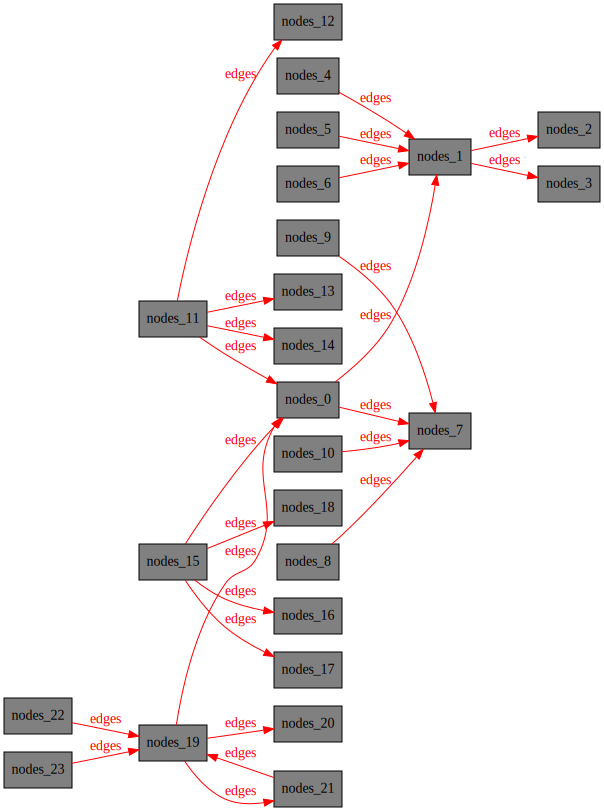

In [17]:
# @title Plot a Subgraph Sample
print("Generating sample for Node 0...")

# Generate a single sample
# Returns a mini-graph containing only the sampled nodes/edges
sample = sampler.sample(seed_node_idxs=0)

# Plot the subgraph
# features=False hides the raw feature vectors to keep the plot clean
dgf.plot.plot_graph(sample, loaded_schema, features=False)

# **Remarks:**

-   `features=False` removes the features from the plot. It is great to
    visualize the topology of the graph.
-   In a sample, the first node (`nodes_0`) is always the one the sampler was
    made around (specified with `seed_node_idxs=0`, a.k.a. the seed node).
-   Sampling one seed node at a time is not very efficient, in practice, it is
    better to provide multiple seed nodes e.g. `seed_node_idxs=[0,1,2]`.
-   Since `seed_node_idxs` is an integer, `sample` returns a single sample. If
    `seed_node_idxs` was a list, `sample` would return a list of samples.

  

## Conclusion🎉

**What we accomplished:**

1. **Loaded** the ogbn-arxiv benchmark dataset into memory.

2. **Transformed** the schema to be compatible with Spanner (fixing types and removing artifacts).

3. **Ingested** 169k nodes and 1.1M edges into Google Cloud Spanner Graph using a high-performance, batched writer.

4. **Verified** the data using distributed processing with Apache Beam.

5. **Visualized** the graph structure by sampling localized subgraphs.

**Next Steps:**
You can now use this Spanner Graph as the backend for large-scale GNN training pipelines, real-time graph queries, or distributed analytics on Dataflow.